<a href="https://colab.research.google.com/github/penkebharathi18/BharathiPenke/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import pandas as pd


In [16]:
import os
os.listdir('/content')


['.config', 'Uber-Jan-Feb-FOIL.csv', 'sample_data']

In [17]:
import pandas as pd

data = pd.read_csv('/content/Uber-Jan-Feb-FOIL.csv')
data.head()


,dispatching_base_number,date,active_vehicles,trips
0,B02512,1/1/2015,190,1132
1,B02765,1/1/2015,225,1765
2,B02764,1/1/2015,3427,29421
3,B02682,1/1/2015,945,7679
4,B02617,1/1/2015,1228,9537


In [18]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   dispatching_base_number  354 non-null    object
 1   date                     354 non-null    object
 2   active_vehicles          354 non-null    int64 
 3   trips                    354 non-null    int64 
dtypes: int64(2), object(2)
memory usage: 11.2+ KB


In [20]:
data['date'] = pd.to_datetime(data['date'])


In [21]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354 entries, 0 to 353
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   dispatching_base_number  354 non-null    object        
 1   date                     354 non-null    datetime64[ns]
 2   active_vehicles          354 non-null    int64         
 3   trips                    354 non-null    int64         
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 11.2+ KB


In [22]:
data['Day'] = data['date'].dt.day
data['Month'] = data['date'].dt.month
data['DayOfWeek'] = data['date'].dt.dayofweek


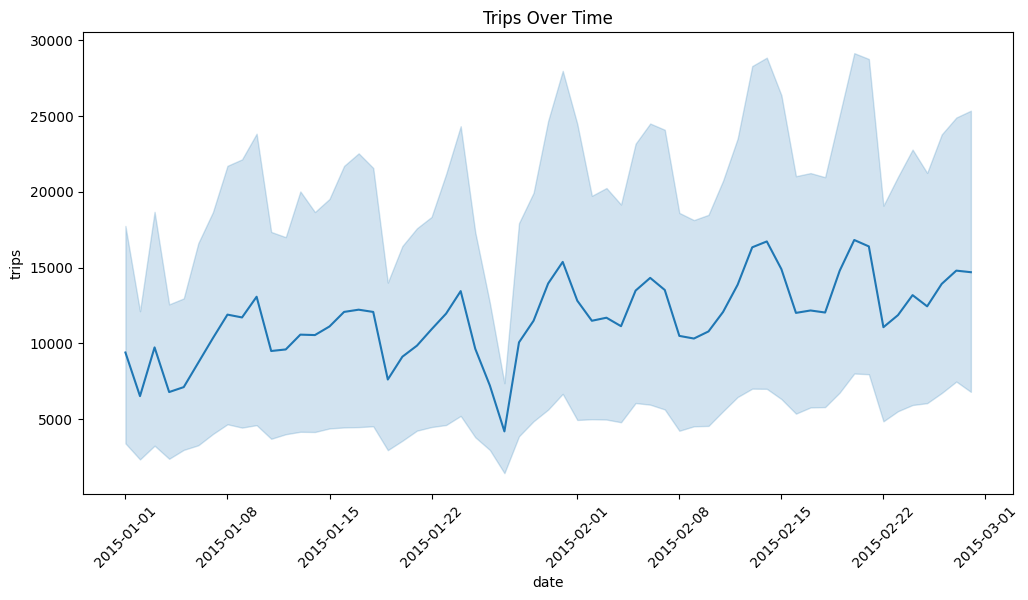

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.lineplot(x='date', y='trips', data=data)
plt.title('Trips Over Time')
plt.xticks(rotation=45)
plt.show()


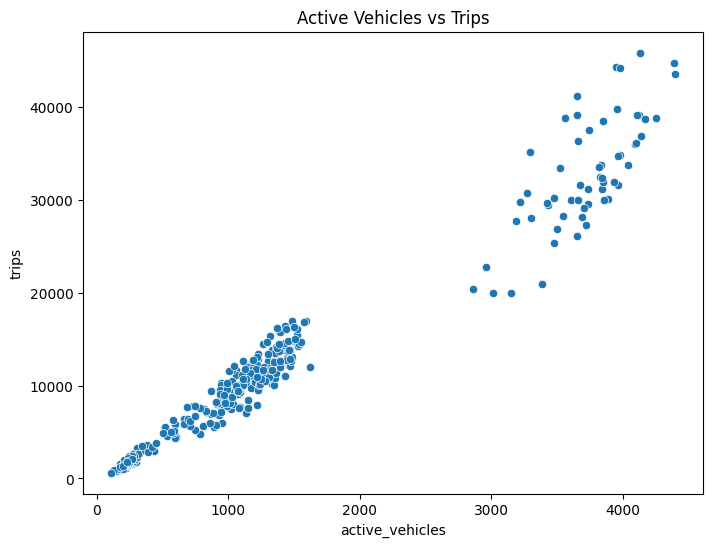

In [24]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='active_vehicles', y='trips', data=data)
plt.title('Active Vehicles vs Trips')
plt.show()


In [25]:
data = pd.get_dummies(
    data,
    columns=['dispatching_base_number'],
    drop_first=True
)


In [26]:
X = data.drop(columns=['trips', 'date'])
y = data['trips']


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


In [28]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [29]:
y_pred = model.predict(X_test)


In [30]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 1571358.7030747659
R2 Score: 0.9869284521862113
